## Seaborn

1. Подключение к db.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("../data/checking-logs.sqlite")

2. Формирование датафрейма.

In [2]:
query = """
SELECT uid, timestamp, numTrials
FROM checker
WHERE uid NOT LIKE 'admin%' 
AND labname = 'project1'
AND status = 'ready'
"""

df = pd.read_sql(query, conn)

df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values(by=['uid', 'timestamp', 'numTrials'])

3. Построение графика.

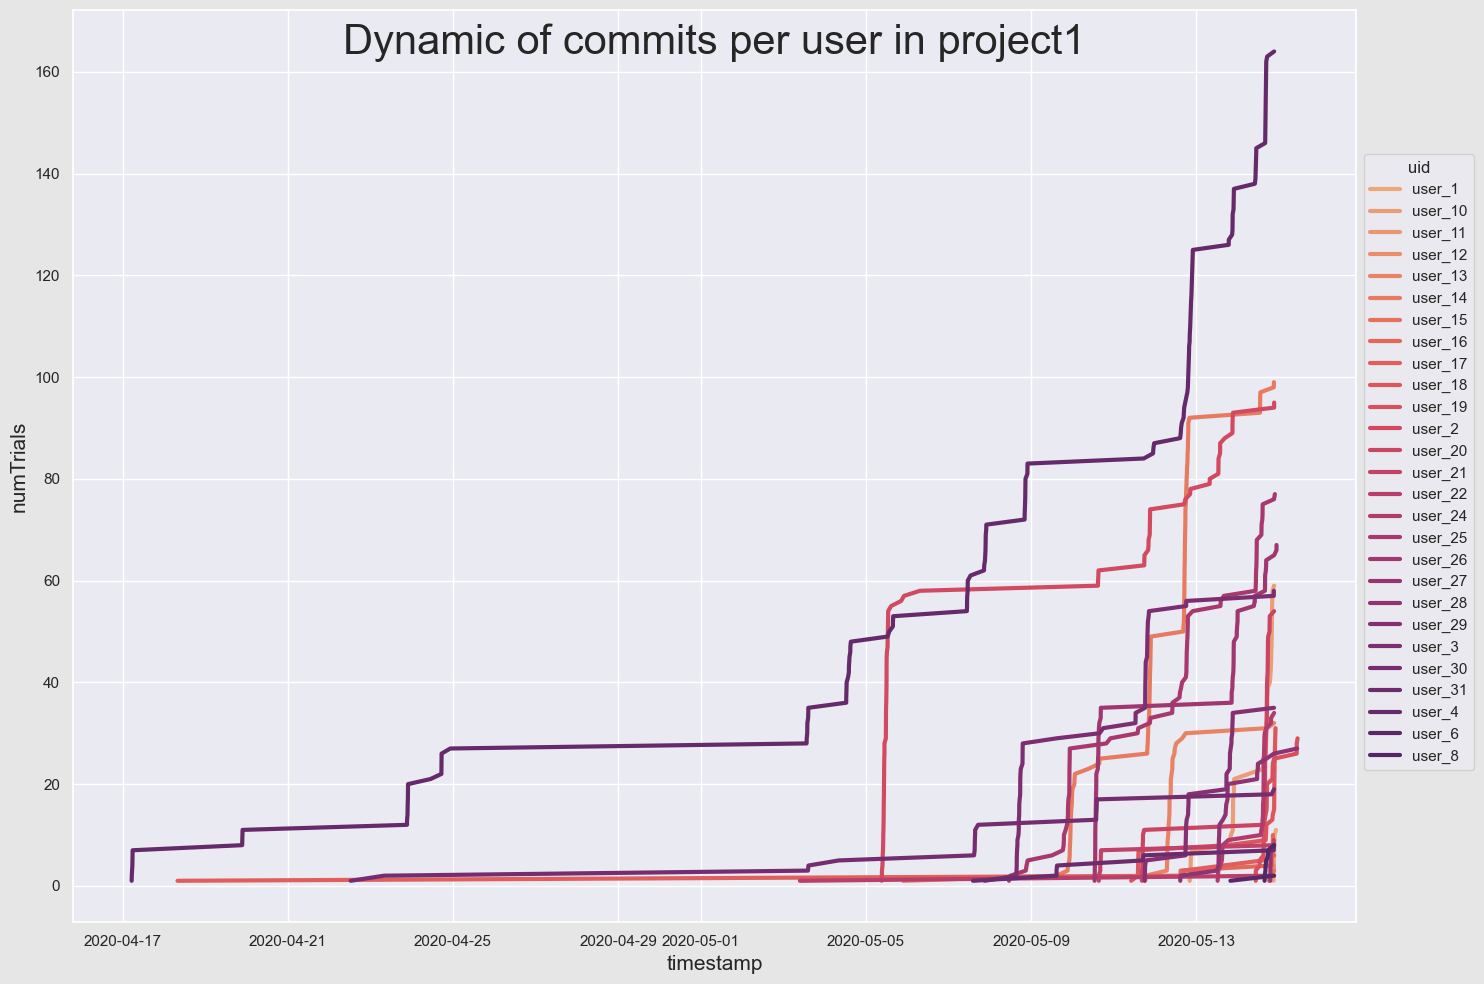

In [3]:
height = 10
width = height * 1.5
sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(figsize=(width, height))

graph = sns.lineplot(data=df, x="timestamp", y="numTrials", hue='uid', linewidth=3, palette='flare')
graph.set_title('Dynamic of commits per user in project1', fontsize=30, pad=1, y=0.95)


graph.legend(bbox_to_anchor=(1, 0.85), title='uid')
graph.set_xlabel('timestamp', fontsize=15)
graph.set_ylabel('numTrials', fontsize=15)

plt.tight_layout()
fig.patch.set_facecolor('#e6e6e6')

In [4]:
conn.close()

Вопросы:

Какой пользователь лидировал по количеству коммитов почти всё время? 
Ответ: user_4.

Какой пользователь лидировал только короткий период времени? 
Ответ: user_2.